# ECG R-peak → RR → HRV branch: Windows/Jupyter teaching notebook

This notebook contains the complete currently implemented branch in one place:

1. discover the local project datasets and select a verified ECG channel;
2. load a chosen time segment in physical units;
3. run NeuroKit2 Pan–Tompkins and NeuroKit R-peak pipelines;
4. compare their peak locations with one-to-one 75 ms matching;
5. if a WFDB \`.atr\` file is present, compare both detectors with expert beat annotations;
6. convert the selected peak sequence into RR intervals and instantaneous heart rate;
7. apply the causal seven-RR median filter;
8. calculate 100-RR Poincaré SD1/SD2, CSI, filtered modified CSI, absolute HR slope, J1 and J2;
9. export every intermediate value.

**Scientific boundary:** this is a feature extractor, not a trained seizure classifier. J1 and J2 are continuous measurements, not seizure probabilities. No seizure threshold is applied.

**Primary evidence**

- Pan and Tompkins, 1985: https://doi.org/10.1109/TBME.1985.325532
- NeuroKit2: https://doi.org/10.3758/s13428-020-01516-y
- R-peak benchmark and ±75 ms same-QRS tolerance: https://doi.org/10.1371/journal.pdig.0000538
- Jeppesen phase-3 HRV method: https://doi.org/10.1016/j.ebiom.2025.105952
- MIT-BIH Arrhythmia data: https://physionet.org/content/mitdb/1.0.0/
- MIT-BIH Noise Stress data: https://physionet.org/content/nstdb/1.0.0/

Run the cells from top to bottom. Read the explanation immediately above and below each plot.


## Part 0 — Verify the local Windows environment

This notebook runs inside the project virtual environment at \`feature_extraction\\.venv\`. NeuroKit2 0.2.13 supplies both R-peak pipelines, pyEDFlib reads CHB-MIT-style EDF files, and WFDB reads MIT-BIH \`.hea/.dat/.atr\` records. The next cell verifies the environment without installing or upgrading packages inside a running notebook.

Launch JupyterLab from PowerShell with:

\`\`\`powershell
cd C:\\Users\\Salam\\Documents\\ECGdetector
.\\feature_extraction\\.venv\\Scripts\\python.exe -m jupyter lab
\`\`\`


In [1]:
from importlib.metadata import PackageNotFoundError, version

required_versions = {
    "jupyterlab": "4.6.2",
    "neurokit2": "0.2.13",
    "pyEDFlib": "0.1.42",
    "wfdb": "4.3.1",
}
environment_rows = []
for package, expected in required_versions.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    matches = installed == expected
    environment_rows.append((package, expected, installed, matches))
    print(f"{package:12s} expected={expected:8s} installed={installed!s:8s} match={matches}")
if not all(row[3] for row in environment_rows):
    raise RuntimeError(
        "This kernel is not the prepared project environment. "
        "Stop Jupyter and launch it with the PowerShell command above."
    )


jupyterlab   expected=4.6.2    installed=4.6.2    match=True
neurokit2    expected=0.2.13   installed=0.2.13   match=True
pyEDFlib     expected=0.1.42   installed=0.1.42   match=True
wfdb         expected=4.3.1    installed=4.3.1    match=True


In [2]:
from __future__ import annotations

import json
import math
import shutil
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd
import pyedflib
import wfdb
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

print("Python:", sys.version.split()[0])
print("NeuroKit2:", nk.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("pyEDFlib:", pyedflib.__version__)
print("WFDB:", wfdb.__version__)


Python: 3.12.10
NeuroKit2: 0.2.13
NumPy: 2.4.2
pandas: 2.3.3
pyEDFlib: 0.1.42
WFDB: 4.3.1


## Part 1 — Locate the Windows project and available datasets

The notebook searches upward from its current working directory until it finds both \`Datasets\` and \`feature_extraction\`. It does not upload, copy, unzip, or modify source recordings.

- EDF input is a complete \`.edf\` path.
- WFDB input is the shared path stem without \`.hea\`, \`.dat\`, or \`.atr\`.
- WFDB expert beat annotations are read automatically when an \`.atr\` file exists.
- Every iteration is saved under \`output\\notebook_runs\\RUN_NAME\`.


In [3]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "Datasets").is_dir() and (candidate / "feature_extraction").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find the ECGdetector project root. Launch JupyterLab from "
        "C:\\Users\\Salam\\Documents\\ECGdetector."
    )

PROJECT_ROOT = find_project_root()
DATASETS_ROOT = PROJECT_ROOT / "Datasets"
OUTPUT_ROOT = PROJECT_ROOT / "output" / "notebook_runs"

dataset_rows = []
for folder in sorted(path for path in DATASETS_ROOT.iterdir() if path.is_dir()):
    dataset_rows.append({
        "folder": folder.name,
        "edf_files": sum(1 for _ in folder.rglob("*.edf")),
        "wfdb_headers": sum(1 for _ in folder.rglob("*.hea")),
        "wfdb_annotations": sum(1 for _ in folder.rglob("*.atr")),
    })

print("Project root:", PROJECT_ROOT)
print("Datasets root:", DATASETS_ROOT)
print("Iteration outputs:", OUTPUT_ROOT)
display(pd.DataFrame(dataset_rows))


Project root: C:\Users\Salam\Documents\ECGdetector
Datasets root: C:\Users\Salam\Documents\ECGdetector\Datasets
Iteration outputs: C:\Users\Salam\Documents\ECGdetector\output\notebook_runs


,folder,edf_files,wfdb_headers,wfdb_annotations
0,chb04_28,1,0,0
1,mit-bih-arrhythmia-database-1.0,0,71,72
2,mit-bih-noise-stress-test-database-1.0,0,30,12


In [4]:
# -------------------------- EDIT THIS CELL --------------------------
SOURCE_KIND = "EDF"                  # "EDF" or "WFDB"
SOURCE_PATH = DATASETS_ROOT / "chb04_28" / "chb04_28.edf"
CHANNEL_LABEL = "ECG"               # e.g. "ECG", "EKG EKG", "MLII", or "V5"

# MIT-BIH clean example (uncomment all three lines together):
# SOURCE_KIND = "WFDB"
# SOURCE_PATH = DATASETS_ROOT / "mit-bih-arrhythmia-database-1.0" / "mit-bih-arrhythmia-database-1.0.0" / "100"
# CHANNEL_LABEL = "MLII"

# MIT-BIH controlled 0 dB noise example (uncomment all three lines together):
# SOURCE_KIND = "WFDB"
# SOURCE_PATH = DATASETS_ROOT / "mit-bih-noise-stress-test-database-1.0" / "mit-bih-noise-stress-test-database-1.0.0" / "118e00"
# CHANNEL_LABEL = "MLII"

SEGMENT_START_S = 0.0
SEGMENT_DURATION_S = 600.0
RUN_NAME = "chb04_28_interictal_0_600_v01"  # change for every saved iteration

# Events are seconds from the beginning of the complete recording.
# CHB04_28: [(1679, 1781), (3782, 3898)]
# These intervals only shade plots. They never change the feature values.
EVENTS_S = []

PRIMARY_METHOD = "pantompkins1985"  # or "neurokit"
MATCH_TOLERANCE_MS = 75.0
DETAIL_CENTER_S = None              # absolute recording time, or None for automatic

# Optional manual R-peak CSV for EDF or another source.
# Accepted column: sample_in_record OR time_s.
MANUAL_RPEAK_CSV = None
# ------------------------------------------------------------------


## Part 2 — Inspect the source before selecting a channel

This is a safety step. The code does not assume that the final signal is ECG.

For CHB04_28, the EDF header contains one signal named \`ECG\` at zero-based index 23, sampled at 256 Hz. The accompanying CHB04 summary independently calls it channel 24 ECG. For MIT-BIH, the WFDB header gives names such as MLII and V5.

Run the next cell and verify the displayed name, sampling rate, unit, and duration.


In [5]:
def normalized_source_path(source_kind: str, source_path: str | Path) -> Path:
    path = Path(source_path).expanduser()
    if source_kind.upper() == "WFDB" and path.suffix.lower() in {".hea", ".dat", ".atr"}:
        path = path.with_suffix("")
    return path

def inspect_source(source_kind: str, source_path: str | Path) -> pd.DataFrame:
    kind = source_kind.upper()
    path = normalized_source_path(kind, source_path)

    if kind == "EDF":
        if not path.is_file():
            raise FileNotFoundError(
                f"EDF not found: {path}. Upload/mount it and edit SOURCE_PATH."
            )
        reader = pyedflib.EdfReader(str(path))
        try:
            rows = []
            sample_counts = reader.getNSamples()
            for i, label in enumerate(reader.getSignalLabels()):
                fs = float(reader.getSampleFrequency(i))
                rows.append({
                    "index": i,
                    "label": label.strip(),
                    "sampling_rate_hz": fs,
                    "sample_count": int(sample_counts[i]),
                    "duration_s": int(sample_counts[i]) / fs,
                    "unit": reader.getPhysicalDimension(i).strip(),
                    "physical_min": float(reader.getPhysicalMinimum(i)),
                    "physical_max": float(reader.getPhysicalMaximum(i)),
                })
            return pd.DataFrame(rows)
        finally:
            reader.close()

    if kind == "WFDB":
        header_path = path.with_suffix(".hea")
        if not header_path.is_file():
            raise FileNotFoundError(
                f"WFDB header not found: {header_path}. Keep .hea and .dat together."
            )
        header = wfdb.rdheader(str(path))
        units = header.units or [""] * header.n_sig
        return pd.DataFrame([
            {
                "index": i,
                "label": header.sig_name[i],
                "sampling_rate_hz": float(header.fs),
                "sample_count": int(header.sig_len),
                "duration_s": float(header.sig_len / header.fs),
                "unit": units[i],
                "physical_min": np.nan,
                "physical_max": np.nan,
            }
            for i in range(header.n_sig)
        ])

    raise ValueError("SOURCE_KIND must be 'EDF' or 'WFDB'")

channel_table = inspect_source(SOURCE_KIND, SOURCE_PATH)
display(channel_table)


,index,label,sampling_rate_hz,sample_count,duration_s,unit,physical_min,physical_max
0,0,FP1-F7,256.0,3692288,14423.0,uV,-800.0,800.0
1,1,F7-T7,256.0,3692288,14423.0,uV,-800.0,800.0
2,2,T7-P7,256.0,3692288,14423.0,uV,-800.0,800.0
3,3,P7-O1,256.0,3692288,14423.0,uV,-800.0,800.0
4,4,FP1-F3,256.0,3692288,14423.0,uV,-800.0,800.0
5,5,F3-C3,256.0,3692288,14423.0,uV,-800.0,800.0
6,6,C3-P3,256.0,3692288,14423.0,uV,-800.0,800.0
7,7,P3-O1,256.0,3692288,14423.0,uV,-800.0,800.0
8,8,FP2-F4,256.0,3692288,14423.0,uV,-800.0,800.0
9,9,F4-C4,256.0,3692288,14423.0,uV,-800.0,800.0


**Do not continue until the chosen label is defensible.** A label match establishes what the file declares; the first raw-signal plot provides an additional visual check. Neither replaces dataset documentation when a header is ambiguous.


## Part 3 — Load one ECG segment and plot the raw physical signal

The loader uses an exact, case-insensitive channel-label match. It reads physical values and preserves the source sampling rate. It does not filter, normalize, resample, or remove artifact.

WFDB expert beat annotations are loaded automatically when a matching \`.atr\` file exists. Seizure event intervals and R-peak annotations are different objects.


{'source': 'C:\\Users\\Salam\\Documents\\ECGdetector\\Datasets\\chb04_28\\chb04_28.edf', 'channel': 'ECG', 'channel_index': 23, 'sampling_rate_hz': 256.0, 'unit': 'uV', 'start_s': 0.0, 'duration_s': 600.0, 'samples': 153600, 'reference_beats_in_segment': 0}


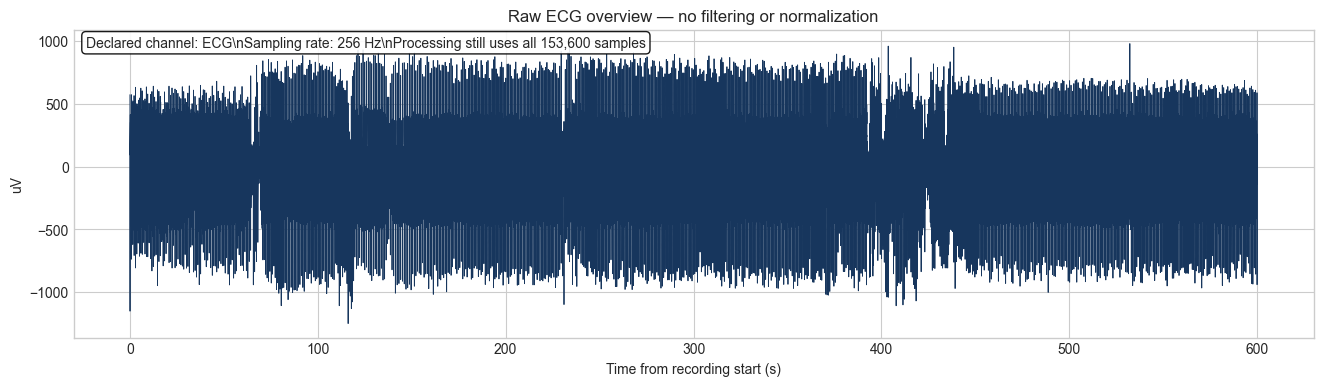

In [11]:
BEAT_SYMBOLS = {
    "N", "L", "R", "a", "V", "F", "J", "A", "S", "E", "j",
    "/", "Q", "e", "n", "f", "r", "B"
}

@dataclass(frozen=True)
class SignalSegment:
    source_kind: str
    path: str
    channel_index: int
    channel_label: str
    unit: str
    sampling_rate_hz: float
    start_s: float
    start_sample_in_record: int
    samples: np.ndarray
    reference_peak_samples: np.ndarray

    @property
    def duration_s(self) -> float:
        return self.samples.size / self.sampling_rate_hz

def choose_channel_index(table: pd.DataFrame, requested_label: str) -> int:
    requested = requested_label.strip().casefold()
    matches = table[table["label"].str.strip().str.casefold() == requested]
    if len(matches) != 1:
        available = ", ".join(table["label"].astype(str))
        raise ValueError(
            f"Expected exactly one channel named {requested_label!r}; "
            f"found {len(matches)}. Available: {available}"
        )
    return int(matches.iloc[0]["index"])

def load_manual_reference(
    csv_path: str | Path,
    *,
    fs: float,
    segment_start_sample: int,
    segment_sample_count: int,
) -> np.ndarray:
    frame = pd.read_csv(csv_path)
    if "sample_in_record" in frame:
        record_samples = frame["sample_in_record"].to_numpy(dtype=np.int64)
    elif "time_s" in frame:
        record_samples = np.rint(frame["time_s"].to_numpy(float) * fs).astype(np.int64)
    else:
        raise ValueError("Manual CSV needs sample_in_record or time_s")
    relative = record_samples - segment_start_sample
    return relative[(relative >= 0) & (relative < segment_sample_count)]

def load_segment(
    source_kind: str,
    source_path: str | Path,
    channel_label: str,
    start_s: float,
    duration_s: float,
    manual_rpeak_csv: str | Path | None = None,
) -> SignalSegment:
    if start_s < 0 or duration_s <= 0:
        raise ValueError("Require start_s >= 0 and duration_s > 0")

    kind = source_kind.upper()
    path = normalized_source_path(kind, source_path)
    table = inspect_source(kind, path)
    channel_index = choose_channel_index(table, channel_label)
    channel = table.loc[table["index"] == channel_index].iloc[0]
    fs = float(channel["sampling_rate_hz"])
    start_sample = int(round(start_s * fs))
    requested_count = int(round(duration_s * fs))
    total_samples = int(channel["sample_count"])
    if start_sample >= total_samples:
        raise ValueError("Segment starts after the selected channel ends")
    count = min(requested_count, total_samples - start_sample)

    reference = np.array([], dtype=np.int64)

    if kind == "EDF":
        reader = pyedflib.EdfReader(str(path))
        try:
            samples = np.asarray(
                reader.readSignal(channel_index, start=start_sample, n=count),
                dtype=np.float64,
            )
        finally:
            reader.close()
    else:
        record = wfdb.rdrecord(
            str(path),
            sampfrom=start_sample,
            sampto=start_sample + count,
            channels=[channel_index],
            physical=True,
        )
        samples = np.asarray(record.p_signal[:, 0], dtype=np.float64)
        annotation_path = path.with_suffix(".atr")
        if annotation_path.is_file():
            annotation = wfdb.rdann(
                str(path),
                "atr",
                sampfrom=start_sample,
                sampto=start_sample + count,
                shift_samps=True,
            )
            reference = np.asarray(
                [sample for sample, symbol in zip(annotation.sample, annotation.symbol)
                 if symbol in BEAT_SYMBOLS],
                dtype=np.int64,
            )

    if samples.size != count:
        raise RuntimeError(f"Expected {count} samples but read {samples.size}")
    if not np.all(np.isfinite(samples)):
        raise ValueError("The selected segment contains non-finite physical samples")

    if manual_rpeak_csv is not None:
        reference = load_manual_reference(
            manual_rpeak_csv,
            fs=fs,
            segment_start_sample=start_sample,
            segment_sample_count=count,
        )

    return SignalSegment(
        source_kind=kind,
        path=str(path.resolve()),
        channel_index=channel_index,
        channel_label=str(channel["label"]),
        unit=str(channel["unit"]),
        sampling_rate_hz=fs,
        start_s=float(start_s),
        start_sample_in_record=start_sample,
        samples=samples,
        reference_peak_samples=np.unique(reference),
    )

def add_event_shading(axis, events):
    for event_start, event_end in events:
        axis.axvspan(event_start, event_end, color="#F2B134", alpha=0.18)

segment = load_segment(
    SOURCE_KIND,
    SOURCE_PATH,
    CHANNEL_LABEL,
    SEGMENT_START_S,
    SEGMENT_DURATION_S,
    MANUAL_RPEAK_CSV,
)

print({
    "source": segment.path,
    "channel": segment.channel_label,
    "channel_index": segment.channel_index,
    "sampling_rate_hz": segment.sampling_rate_hz,
    "unit": segment.unit,
    "start_s": segment.start_s,
    "duration_s": segment.duration_s,
    "samples": int(segment.samples.size),
    "reference_beats_in_segment": int(segment.reference_peak_samples.size),
})

# Downsample only for the overview plot, never for processing.
max_plot_points = 100_000
stride = max(1, math.ceil(segment.samples.size / max_plot_points))
plot_indices = np.arange(0, segment.samples.size, stride)
plot_time = segment.start_s + plot_indices / segment.sampling_rate_hz

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(plot_time, segment.samples[plot_indices], color="#17365D", linewidth=0.6)
add_event_shading(ax, EVENTS_S)
ax.set(
    title="Raw ECG overview — no filtering or normalization",
    xlabel="Time from recording start (s)",
    ylabel=segment.unit or "physical units",
)
ax.text(
    0.01, 0.98,
    f"Declared channel: {segment.channel_label}\\n"
    f"Sampling rate: {segment.sampling_rate_hz:g} Hz\\n"
    f"Processing still uses all {segment.samples.size:,} samples",
    transform=ax.transAxes, va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
plt.show()


### 


How to read the raw overview

- The blue line is the unmodified selected channel.
- Gold shading, if supplied, marks seizure/event time only.
- Large discontinuities, clipping, flat regions, or movement bursts warn that later peak-derived values may not represent physiology.
- Downsampling is used only to draw the overview efficiently; detector input remains full resolution.


## Part 4 — Run the two R-peak pipelines and visualize their candidate locations

Each pipeline performs its own NeuroKit2 cleaning and then its corresponding detector:

- Pan–Tompkins path: \`ecg_clean(..., method="pantompkins1985")\` followed by \`ecg_peaks(..., method="pantompkins1985")\`;
- NeuroKit path: the same two calls with \`method="neurokit"\`.

Artifact correction is disabled so peaks are not silently inserted, deleted, or shifted after detection.


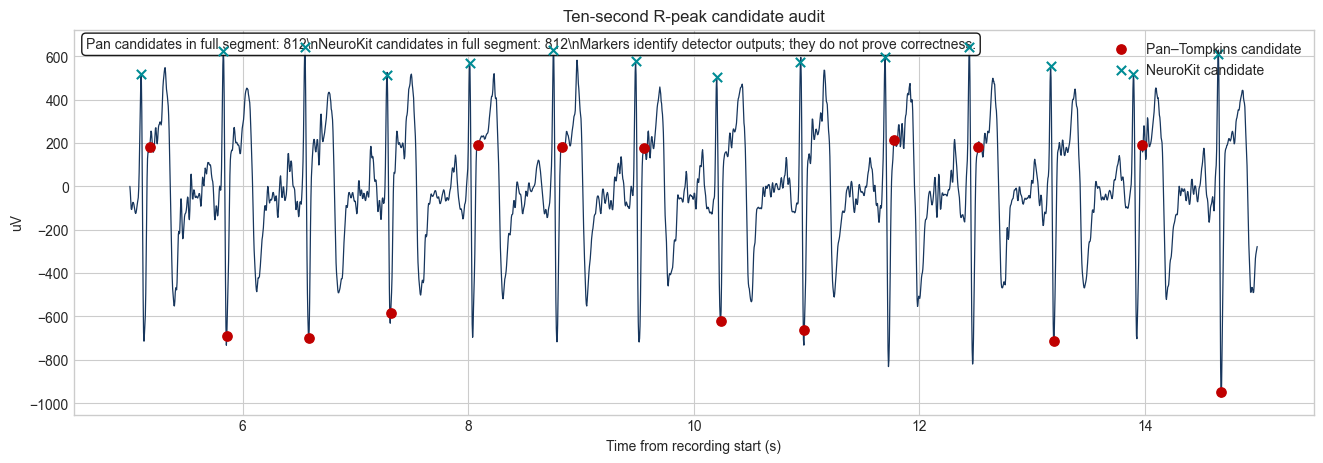

In [7]:
@dataclass(frozen=True)
class PeakDetection:
    method: str
    peak_samples: np.ndarray
    cleaned_ecg: np.ndarray

def detect_r_peaks(signal: np.ndarray, fs: float, method: str) -> PeakDetection:
    signal = np.asarray(signal, dtype=np.float64)
    if signal.ndim != 1:
        raise ValueError("ECG must be one-dimensional")
    if signal.size < int(3 * fs):
        raise ValueError("At least three seconds of ECG are required")
    cleaned = np.asarray(
        nk.ecg_clean(signal, sampling_rate=fs, method=method),
        dtype=np.float64,
    )
    _, info = nk.ecg_peaks(
        cleaned,
        sampling_rate=fs,
        method=method,
        correct_artifacts=False,
    )
    peaks = np.asarray(info["ECG_R_Peaks"], dtype=np.int64)
    return PeakDetection(method, peaks, cleaned)

pan_detection = detect_r_peaks(
    segment.samples, segment.sampling_rate_hz, "pantompkins1985"
)
nk_detection = detect_r_peaks(
    segment.samples, segment.sampling_rate_hz, "neurokit"
)

detections = {
    "pantompkins1985": pan_detection,
    "neurokit": nk_detection,
}
primary_detection = detections[PRIMARY_METHOD]
comparator_method = "neurokit" if PRIMARY_METHOD == "pantompkins1985" else "pantompkins1985"
comparator_detection = detections[comparator_method]

def automatic_detail_center(segment: SignalSegment, events, requested):
    if requested is not None:
        return float(requested)
    overlapping = [
        (a, b) for a, b in events
        if b >= segment.start_s and a <= segment.start_s + segment.duration_s
    ]
    if overlapping:
        return sum(overlapping[0]) / 2
    return segment.start_s + min(10.0, segment.duration_s / 2)

detail_center_s = automatic_detail_center(segment, EVENTS_S, DETAIL_CENTER_S)
detail_half_width_s = 5.0
first = max(0, int(round((detail_center_s - detail_half_width_s - segment.start_s)
                         * segment.sampling_rate_hz)))
last = min(segment.samples.size,
           int(round((detail_center_s + detail_half_width_s - segment.start_s)
                     * segment.sampling_rate_hz)))
detail_indices = np.arange(first, last)
detail_time = segment.start_s + detail_indices / segment.sampling_rate_hz

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(detail_time, segment.samples[first:last], color="#17365D", linewidth=0.9)

for detection, color, marker, label in [
    (pan_detection, "#C00000", "o", "Pan–Tompkins candidate"),
    (nk_detection, "#008C95", "x", "NeuroKit candidate"),
]:
    visible = detection.peak_samples[
        (detection.peak_samples >= first) & (detection.peak_samples < last)
    ]
    ax.scatter(
        segment.start_s + visible / segment.sampling_rate_hz,
        segment.samples[visible],
        s=45, marker=marker, color=color, label=label, zorder=4,
    )

reference_visible = segment.reference_peak_samples[
    (segment.reference_peak_samples >= first)
    & (segment.reference_peak_samples < last)
]
for index, peak in enumerate(reference_visible):
    ax.axvline(
        segment.start_s + peak / segment.sampling_rate_hz,
        color="#6A3D9A", linewidth=1.2, alpha=0.8,
        label="Expert/manual beat annotation" if index == 0 else None,
    )

add_event_shading(ax, EVENTS_S)
ax.set(
    title="Ten-second R-peak candidate audit",
    xlabel="Time from recording start (s)",
    ylabel=segment.unit or "physical units",
)
ax.legend(loc="upper right")
ax.text(
    0.01, 0.98,
    f"Pan candidates in full segment: {pan_detection.peak_samples.size}\\n"
    f"NeuroKit candidates in full segment: {nk_detection.peak_samples.size}\\n"
    "Markers identify detector outputs; they do not prove correctness.",
    transform=ax.transAxes, va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
plt.show()


### What the R-peak plot can and cannot show

A marker on each visible QRS is encouraging. Look for:

- markers placed on P or T waves;
- missing QRS complexes;
- two markers around one complex;
- changing placement within the QRS;
- disagreement during artifact.

Similar total beat counts are insufficient for HRV: shifting a fiducial within a beat changes two adjacent RR intervals.


## Part 5 — Quantify detector agreement and, when possible, accuracy against reference beats

Two candidates match only when they can be paired one-to-one within ±75 ms. The detector-to-detector score is:

\[
A=\frac{2M}{N_P+N_C}.
\]

This is symmetric agreement, not clinical accuracy. If expert WFDB/manual annotations are available, the notebook separately reports sensitivity, PPV, F1, and timing error against that reference.


In [ ]:
@dataclass(frozen=True)
class PeakAgreement:
    matched_primary_samples: np.ndarray
    matched_comparator_samples: np.ndarray
    unmatched_primary_samples: np.ndarray
    unmatched_comparator_samples: np.ndarray
    agreement_f1: float
    median_timing_difference_ms: float
    unmatched_primary_fraction: float
    unmatched_comparator_fraction: float

def compare_peak_sequences(
    primary_samples: np.ndarray,
    comparator_samples: np.ndarray,
    fs: float,
    tolerance_ms: float = 75.0,
) -> PeakAgreement:
    primary = np.unique(np.asarray(primary_samples, dtype=np.int64))
    comparator = np.unique(np.asarray(comparator_samples, dtype=np.int64))
    tolerance_samples = int(round(tolerance_ms * fs / 1000.0))
    if tolerance_samples < 1:
        raise ValueError("Tolerance is smaller than one sample")

    matched_primary, matched_comparator = [], []
    unmatched_primary, unmatched_comparator = [], []
    i = j = 0
    while i < primary.size and j < comparator.size:
        delta = int(primary[i] - comparator[j])
        if abs(delta) <= tolerance_samples:
            matched_primary.append(int(primary[i]))
            matched_comparator.append(int(comparator[j]))
            i += 1
            j += 1
        elif delta < 0:
            unmatched_primary.append(int(primary[i]))
            i += 1
        else:
            unmatched_comparator.append(int(comparator[j]))
            j += 1
    unmatched_primary.extend(primary[i:].tolist())
    unmatched_comparator.extend(comparator[j:].tolist())

    mp = np.asarray(matched_primary, dtype=np.int64)
    mc = np.asarray(matched_comparator, dtype=np.int64)
    up = np.asarray(unmatched_primary, dtype=np.int64)
    uc = np.asarray(unmatched_comparator, dtype=np.int64)
    denominator = primary.size + comparator.size

    return PeakAgreement(
        matched_primary_samples=mp,
        matched_comparator_samples=mc,
        unmatched_primary_samples=up,
        unmatched_comparator_samples=uc,
        agreement_f1=float(2 * mp.size / denominator) if denominator else np.nan,
        median_timing_difference_ms=(
            float(np.median(np.abs(mp - mc)) * 1000 / fs) if mp.size else np.nan
        ),
        unmatched_primary_fraction=(
            float(up.size / primary.size) if primary.size else np.nan
        ),
        unmatched_comparator_fraction=(
            float(uc.size / comparator.size) if comparator.size else np.nan
        ),
    )

def reference_metrics(reference, detected, fs, tolerance_ms=75.0):
    result = compare_peak_sequences(reference, detected, fs, tolerance_ms)
    matched = result.matched_primary_samples.size
    reference_count = np.unique(reference).size
    detected_count = np.unique(detected).size
    sensitivity = matched / reference_count if reference_count else np.nan
    ppv = matched / detected_count if detected_count else np.nan
    f1 = (2 * matched / (reference_count + detected_count)
          if reference_count + detected_count else np.nan)
    return {
        "reference_beats": reference_count,
        "detected_candidates": detected_count,
        "matched": matched,
        "sensitivity": sensitivity,
        "ppv": ppv,
        "f1": f1,
        "median_timing_error_ms": result.median_timing_difference_ms,
    }

agreement = compare_peak_sequences(
    primary_detection.peak_samples,
    comparator_detection.peak_samples,
    segment.sampling_rate_hz,
    MATCH_TOLERANCE_MS,
)

display(pd.DataFrame([{
    "primary": PRIMARY_METHOD,
    "comparator": comparator_method,
    "primary_count": primary_detection.peak_samples.size,
    "comparator_count": comparator_detection.peak_samples.size,
    "matched_count": agreement.matched_primary_samples.size,
    "agreement_f1": agreement.agreement_f1,
    "median_matched_displacement_ms": agreement.median_timing_difference_ms,
    "unmatched_primary_fraction": agreement.unmatched_primary_fraction,
    "unmatched_comparator_fraction": agreement.unmatched_comparator_fraction,
}]))

if segment.reference_peak_samples.size:
    reference_table = pd.DataFrame([
        {"detector": "Pan–Tompkins", **reference_metrics(
            segment.reference_peak_samples,
            pan_detection.peak_samples,
            segment.sampling_rate_hz,
            MATCH_TOLERANCE_MS,
        )},
        {"detector": "NeuroKit", **reference_metrics(
            segment.reference_peak_samples,
            nk_detection.peak_samples,
            segment.sampling_rate_hz,
            MATCH_TOLERANCE_MS,
        )},
    ])
    print("Accuracy against expert/manual beat annotations:")
    display(reference_table)
else:
    print(
        "No reference R-peak annotations were found. "
        "Detector agreement cannot determine which detector is correct."
    )

tolerances = np.array([20, 50, 75, 100, 125, 150], dtype=float)
tolerance_scores = [
    compare_peak_sequences(
        primary_detection.peak_samples,
        comparator_detection.peak_samples,
        segment.sampling_rate_hz,
        tolerance,
    ).agreement_f1
    for tolerance in tolerances
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(tolerances, tolerance_scores, marker="o", color="#17365D")
axes[0].axvline(75, color="#C00000", linestyle="--", label="Published ±75 ms")
axes[0].set(
    title="Detector agreement changes with matching tolerance",
    xlabel="Tolerance (ms)",
    ylabel="Symmetric agreement F1",
    ylim=(0, 1.03),
)
axes[0].legend()

audit_center_sample = (
    int(agreement.unmatched_primary_samples[0])
    if agreement.unmatched_primary_samples.size
    else int(round((detail_center_s - segment.start_s) * segment.sampling_rate_hz))
)
audit_half = int(round(5 * segment.sampling_rate_hz))
audit_first = max(0, audit_center_sample - audit_half)
audit_last = min(segment.samples.size, audit_center_sample + audit_half)
audit_indices = np.arange(audit_first, audit_last)
audit_time = segment.start_s + audit_indices / segment.sampling_rate_hz
axes[1].plot(audit_time, segment.samples[audit_first:audit_last],
             color="#17365D", linewidth=0.9)

for peaks, color, marker, label in [
    (agreement.matched_primary_samples, "#2E8B57", "o", "Matched primary"),
    (agreement.unmatched_primary_samples, "#C00000", "x", "Unmatched primary"),
    (agreement.unmatched_comparator_samples, "#E67E22", "+", "Unmatched comparator"),
]:
    visible = peaks[(peaks >= audit_first) & (peaks < audit_last)]
    axes[1].scatter(
        segment.start_s + visible / segment.sampling_rate_hz,
        segment.samples[visible],
        color=color, marker=marker, s=55, label=label, zorder=4,
    )

axes[1].set(
    title="Ten-second disagreement audit",
    xlabel="Time from recording start (s)",
    ylabel=segment.unit or "physical units",
)
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()


### Critical interpretation

- A high detector-agreement score means the two algorithms usually nominate nearby locations.
- It does not establish truth unless a manual/reference annotation is available.
- The median displacement excludes all unmatched candidates and must be read with unmatched fractions.
- Raising the tolerance can hide unstable fiducial placement; it does not repair RR timing.
- MIT-BIH and Noise Stress \`.atr\` files provide reference beats. CHB04 seizure files do not provide reference R peaks.


## Part 6 — Convert selected R peaks into RR intervals and instantaneous BPM

For consecutive selected peaks \(p_{i-1}\) and \(p_i\):

\[
RR_i = 1000\frac{p_i-p_{i-1}}{f_s}\ {\rm ms},
\qquad
HR_i = \frac{60000}{RR_i}\ {\rm bpm}.
\]

The row time is the time of the R peak ending the interval. No physiological bounds or ectopic-beat correction are applied.


In [ ]:
def causal_median_filter(values: np.ndarray, width: int = 7) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if width <= 0:
        raise ValueError("Median width must be positive")
    result = np.empty_like(values)
    for i in range(values.size):
        first = max(0, i - width + 1)
        result[i] = np.median(values[first:i + 1])
    return result

primary_peaks = np.unique(primary_detection.peak_samples.astype(np.int64))
if primary_peaks.size < 2:
    raise ValueError("At least two primary peaks are required")

rr_ms = np.diff(primary_peaks) * 1000.0 / segment.sampling_rate_hz
rr_time_s = segment.start_s + primary_peaks[1:] / segment.sampling_rate_hz
heart_rate_bpm = 60000.0 / rr_ms
rr_filtered_ms = causal_median_filter(rr_ms, width=7)
filtered_hr_bpm = 60000.0 / rr_filtered_ms

rr_basic = pd.DataFrame({
    "time_s": rr_time_s,
    "rr_ms": rr_ms,
    "heart_rate_bpm": heart_rate_bpm,
    "rr_median7_ms": rr_filtered_ms,
})
display(rr_basic.head(10))

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Explain a few individual RR intervals on ECG.
explain_center = int(round((detail_center_s - segment.start_s)
                           * segment.sampling_rate_hz))
visible_peaks = primary_peaks[
    (primary_peaks >= explain_center - int(4 * segment.sampling_rate_hz))
    & (primary_peaks <= explain_center + int(4 * segment.sampling_rate_hz))
]
if visible_peaks.size < 4:
    visible_peaks = primary_peaks[:min(8, primary_peaks.size)]
ecg_first = max(0, int(visible_peaks[0] - 0.5 * segment.sampling_rate_hz))
ecg_last = min(segment.samples.size,
               int(visible_peaks[-1] + 0.5 * segment.sampling_rate_hz))
ecg_idx = np.arange(ecg_first, ecg_last)
axes[0].plot(
    segment.start_s + ecg_idx / segment.sampling_rate_hz,
    segment.samples[ecg_first:ecg_last],
    color="#17365D", linewidth=0.9,
)
visible_peaks = visible_peaks[
    (visible_peaks >= ecg_first) & (visible_peaks < ecg_last)
]
axes[0].scatter(
    segment.start_s + visible_peaks / segment.sampling_rate_hz,
    segment.samples[visible_peaks],
    color="#C00000", s=45, zorder=4, label="Selected R peaks",
)
y_top = np.nanmax(segment.samples[ecg_first:ecg_last])
y_bottom = np.nanmin(segment.samples[ecg_first:ecg_last])
arrow_y = y_bottom + 0.08 * (y_top - y_bottom)
for left_peak, right_peak in zip(visible_peaks[:4], visible_peaks[1:5]):
    left_t = segment.start_s + left_peak / segment.sampling_rate_hz
    right_t = segment.start_s + right_peak / segment.sampling_rate_hz
    interval_ms = (right_peak - left_peak) * 1000 / segment.sampling_rate_hz
    axes[0].annotate(
        "", xy=(right_t, arrow_y), xytext=(left_t, arrow_y),
        arrowprops={"arrowstyle": "<->", "color": "#2E8B57", "linewidth": 1.5},
    )
    axes[0].text(
        (left_t + right_t) / 2, arrow_y,
        f"{interval_ms:.0f} ms", ha="center", va="bottom", color="#2E8B57",
    )
axes[0].set(
    title="How an RR interval is measured: time between consecutive selected peaks",
    xlabel="Time from recording start (s)",
    ylabel=segment.unit or "physical units",
)
axes[0].legend()

axes[1].plot(rr_time_s, rr_ms, color="#17365D", linewidth=0.8,
             label="Raw RR interval")
axes[1].set(
    title="RR tachogram from the selected detector",
    xlabel="Time of interval-ending R peak (s)",
    ylabel="RR (ms)",
)
add_event_shading(axes[1], EVENTS_S)
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(rr_time_s, heart_rate_bpm, color="#008C95", linewidth=0.8)
add_event_shading(ax, EVENTS_S)
ax.set(
    title="Instantaneous heart rate = 60,000 / RR",
    xlabel="Time from recording start (s)",
    ylabel="Heart rate (bpm)",
)
ax.text(
    0.01, 0.98,
    f"Minimum observed RR: {np.min(rr_ms):.1f} ms\\n"
    f"Maximum observed RR: {np.max(rr_ms):.1f} ms\\n"
    "No physiological rejection rule has been applied.",
    transform=ax.transAxes, va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
plt.show()


### What to inspect before continuing

Very short or very long RR values may represent true rhythm changes, ectopic beats, missed beats, extra detections, or artifact. The notebook deliberately preserves them. A clean-looking HR curve does not retroactively validate the peaks.


## Part 7 — Apply the causal seven-RR median filter

For interval \(i\), the filtered value is the median of the current interval and at most six preceding intervals:

\[
\widetilde{RR}_i = \operatorname{median}(RR_{\max(0,i-6)},\ldots,RR_i).
\]

No future RR interval is used. The first six rows have shorter histories.


In [ ]:
difference_ms = np.abs(rr_ms - rr_filtered_ms)
largest_change_index = int(np.argmax(difference_ms))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rr_time_s, rr_ms, color="#9E9E9E", linewidth=0.8, alpha=0.8,
        label="Raw RR")
ax.plot(rr_time_s, rr_filtered_ms, color="#C00000", linewidth=1.2,
        label="Causal median-7 RR")
add_event_shading(ax, EVENTS_S)

x = rr_time_s[largest_change_index]
ax.scatter([x], [rr_filtered_ms[largest_change_index]], color="#C00000", s=60, zorder=5)
ax.annotate(
    f"Largest displayed change\\nraw={rr_ms[largest_change_index]:.1f} ms\\n"
    f"filtered={rr_filtered_ms[largest_change_index]:.1f} ms",
    xy=(x, rr_filtered_ms[largest_change_index]),
    xytext=(15, 40), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#C00000"},
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
ax.set(
    title="Raw RR versus causal seven-interval median",
    xlabel="Time from recording start (s)",
    ylabel="RR (ms)",
)
ax.legend()
plt.show()


The median path reduces isolated RR excursions, but it does not prove that a changed value was artifact. It is a published preprocessing component of the selected Jeppesen feature path, not a general-purpose correction of every abnormal interval.


## Part 8 — Compute the complete 100-RR feature table

Each feature row after warm-up uses 100 RR intervals. Adjacent rows overlap by 99 intervals.

For successive RR values:

\[
SD1 = SD\left(\frac{RR_{i+1}-RR_i}{\sqrt{2}}\right),\qquad
SD2 = SD\left(\frac{RR_{i+1}+RR_i}{\sqrt{2}}\right).
\]

Then:

\[
CSI_{100}=\frac{SD2_{raw}}{SD1_{raw}},
\]

\[
ModCSI^{(7)}_{100}=\frac{(4SD2_{filtered})^2}{4SD1_{filtered}},
\]

\[
J1=CSI_{100}\times |Slope|,\qquad
J2=ModCSI^{(7)}_{100}\times |Slope|.
\]

Slope is fitted to filtered heart rate against actual elapsed seconds.


In [ ]:
def poincare_axes(rr_window_ms: np.ndarray) -> tuple[float, float]:
    rr = np.asarray(rr_window_ms, dtype=np.float64)
    if rr.size < 3 or not np.all(np.isfinite(rr)):
        return np.nan, np.nan
    x1 = rr[:-1]
    x2 = rr[1:]
    sd1 = np.std((x2 - x1) / np.sqrt(2.0), ddof=1)
    sd2 = np.std((x2 + x1) / np.sqrt(2.0), ddof=1)
    return float(sd1), float(sd2)

def signed_least_squares_slope(
    time_s: np.ndarray, heart_rate_bpm: np.ndarray
) -> float:
    time_s = np.asarray(time_s, dtype=np.float64)
    heart_rate_bpm = np.asarray(heart_rate_bpm, dtype=np.float64)
    if time_s.size < 2 or not np.all(np.isfinite(time_s + heart_rate_bpm)):
        return np.nan
    centered_time = time_s - np.mean(time_s)
    denominator = np.sum(centered_time ** 2)
    if denominator <= 0:
        return np.nan
    numerator = np.sum(
        centered_time * (heart_rate_bpm - np.mean(heart_rate_bpm))
    )
    return float(numerator / denominator)

def count_in_closed_interval(values: np.ndarray, first: int, last: int) -> int:
    values = np.asarray(values, dtype=np.int64)
    left = np.searchsorted(values, first, side="left")
    right = np.searchsorted(values, last, side="right")
    return int(right - left)

def extract_rr_hrv_features(
    peak_samples: np.ndarray,
    fs: float,
    segment_start_s: float,
    agreement: PeakAgreement,
    window_size: int = 100,
    median_width: int = 7,
) -> pd.DataFrame:
    peaks = np.unique(np.asarray(peak_samples, dtype=np.int64))
    if peaks.size < 2:
        raise ValueError("At least two R peaks are required")
    if window_size < 3:
        raise ValueError("window_size must be at least 3")

    rr = np.diff(peaks) * 1000.0 / fs
    interval_time = segment_start_s + peaks[1:] / fs
    hr = 60000.0 / rr
    rr_filtered = causal_median_filter(rr, median_width)
    hr_filtered = 60000.0 / rr_filtered

    frame = pd.DataFrame({
        "time_s": interval_time,
        "r_peak_sample_in_record": (
            segment.start_sample_in_record + peaks[1:]
        ).astype(np.int64),
        "rr_ms": rr,
        "heart_rate_bpm": hr,
        f"rr_median{median_width}_ms": rr_filtered,
        "window_rr_count": np.minimum(np.arange(1, rr.size + 1), window_size),
        "sd1_raw_ms": np.nan,
        "sd2_raw_ms": np.nan,
        "csi100": np.nan,
        "sd1_filtered_ms": np.nan,
        "sd2_filtered_ms": np.nan,
        "modcsi100_filtered_ms": np.nan,
        "signed_slope100_bpm_per_s": np.nan,
        "slope100_bpm_per_s": np.nan,
        "j1_csi_x_slope": np.nan,
        "j2_modcsi_filtered_x_slope": np.nan,
        "feature_defined": False,
        "window_has_detector_disagreement": False,
        "unmatched_primary_count": 0,
        "unmatched_comparator_count": 0,
    })

    for end in range(window_size - 1, rr.size):
        first = end - window_size + 1
        raw_window = rr[first:end + 1]
        filtered_window = rr_filtered[first:end + 1]
        time_window = interval_time[first:end + 1]
        filtered_hr_window = hr_filtered[first:end + 1]

        sd1_raw, sd2_raw = poincare_axes(raw_window)
        sd1_filtered, sd2_filtered = poincare_axes(filtered_window)
        csi = sd2_raw / sd1_raw if np.isfinite(sd1_raw) and sd1_raw > 0 else np.nan
        modcsi = (
            (4 * sd2_filtered) ** 2 / (4 * sd1_filtered)
            if np.isfinite(sd1_filtered) and sd1_filtered > 0 else np.nan
        )
        signed_slope = signed_least_squares_slope(time_window, filtered_hr_window)
        slope = abs(signed_slope) if np.isfinite(signed_slope) else np.nan
        j1 = csi * slope if np.isfinite(csi * slope) else np.nan
        j2 = modcsi * slope if np.isfinite(modcsi * slope) else np.nan

        window_start_sample = peaks[first]
        window_end_sample = peaks[end + 1]
        primary_disagreements = count_in_closed_interval(
            agreement.unmatched_primary_samples,
            window_start_sample,
            window_end_sample,
        )
        comparator_disagreements = count_in_closed_interval(
            agreement.unmatched_comparator_samples,
            window_start_sample,
            window_end_sample,
        )

        frame.loc[end, [
            "sd1_raw_ms", "sd2_raw_ms", "csi100",
            "sd1_filtered_ms", "sd2_filtered_ms",
            "modcsi100_filtered_ms",
            "signed_slope100_bpm_per_s", "slope100_bpm_per_s",
            "j1_csi_x_slope", "j2_modcsi_filtered_x_slope",
        ]] = [
            sd1_raw, sd2_raw, csi,
            sd1_filtered, sd2_filtered, modcsi,
            signed_slope, slope, j1, j2,
        ]
        frame.loc[end, "feature_defined"] = bool(
            np.isfinite(j1) and np.isfinite(j2)
        )
        frame.loc[end, "unmatched_primary_count"] = primary_disagreements
        frame.loc[end, "unmatched_comparator_count"] = comparator_disagreements
        frame.loc[end, "window_has_detector_disagreement"] = bool(
            primary_disagreements or comparator_disagreements
        )

    return frame

features = extract_rr_hrv_features(
    primary_detection.peak_samples,
    segment.sampling_rate_hz,
    segment.start_s,
    agreement,
)

print("Rows:", len(features))
print("Rows with a complete finite 100-RR feature:", int(features["feature_defined"].sum()))
print("First complete row index:", features.index[features["feature_defined"]].min()
      if features["feature_defined"].any() else None)
display(features.head(105).tail(10))


## Part 9 — Visualize one 100-RR Poincaré window and its fitted HR slope

The left plot uses raw RR pairs. SD1 is the short perpendicular spread; SD2 is spread along the identity line. The middle plot shows the median-filtered RR pairs used for modified CSI. The right plot shows filtered heart rate and its least-squares line.

Choose another complete feature row by changing \`EXAMPLE_FEATURE_ROW\`.


In [ ]:
complete_rows = features.index[features["feature_defined"]].to_numpy()
if complete_rows.size == 0:
    raise ValueError(
        "No complete 100-RR feature exists. Load a longer segment or inspect peak failure."
    )

EXAMPLE_FEATURE_ROW = int(complete_rows[len(complete_rows) // 2])
window_first = EXAMPLE_FEATURE_ROW - 99
window_last = EXAMPLE_FEATURE_ROW + 1

example_raw_rr = features.loc[window_first:EXAMPLE_FEATURE_ROW, "rr_ms"].to_numpy()
example_filtered_rr = features.loc[
    window_first:EXAMPLE_FEATURE_ROW, "rr_median7_ms"
].to_numpy()
example_time = features.loc[window_first:EXAMPLE_FEATURE_ROW, "time_s"].to_numpy()
example_filtered_hr = 60000.0 / example_filtered_rr

def plot_poincare(axis, rr_values, title, color):
    x = rr_values[:-1]
    y = rr_values[1:]
    center = np.array([np.mean(x), np.mean(y)])
    sd1, sd2 = poincare_axes(rr_values)
    axis.scatter(x, y, s=20, alpha=0.65, color=color)
    limits = [min(x.min(), y.min()), max(x.max(), y.max())]
    padding = max(1.0, 0.08 * (limits[1] - limits[0]))
    limits = [limits[0] - padding, limits[1] + padding]
    axis.plot(limits, limits, linestyle="--", color="#777777", label="Identity line")
    # Axis arrows are illustrative orientations; labels report computed SD values.
    axis.annotate(
        "", xy=center + np.array([sd2, sd2]) / np.sqrt(2),
        xytext=center - np.array([sd2, sd2]) / np.sqrt(2),
        arrowprops={"arrowstyle": "<->", "color": "#17365D", "linewidth": 2},
    )
    axis.annotate(
        "", xy=center + np.array([-sd1, sd1]) / np.sqrt(2),
        xytext=center - np.array([-sd1, sd1]) / np.sqrt(2),
        arrowprops={"arrowstyle": "<->", "color": "#C00000", "linewidth": 2},
    )
    axis.text(
        0.03, 0.97, f"SD1={sd1:.2f} ms\\nSD2={sd2:.2f} ms",
        transform=axis.transAxes, va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
    )
    axis.set(
        title=title,
        xlabel="RR(n) (ms)",
        ylabel="RR(n+1) (ms)",
        xlim=limits, ylim=limits,
    )
    axis.set_aspect("equal", adjustable="box")

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
plot_poincare(axes[0], example_raw_rr, "Raw 100-RR Poincaré plot", "#008C95")
plot_poincare(
    axes[1], example_filtered_rr,
    "Median-7 filtered 100-RR Poincaré plot", "#C00000"
)

signed_slope = signed_least_squares_slope(example_time, example_filtered_hr)
fitted_hr = (
    np.mean(example_filtered_hr)
    + signed_slope * (example_time - np.mean(example_time))
)
axes[2].plot(example_time, example_filtered_hr, color="#9E9E9E",
             marker=".", markersize=3, linewidth=0.7, label="Filtered HR")
axes[2].plot(example_time, fitted_hr, color="#17365D", linewidth=2,
             label="Least-squares line")
axes[2].text(
    0.03, 0.97,
    f"Signed slope={signed_slope:.4f} bpm/s\\n"
    f"Exported |slope|={abs(signed_slope):.4f} bpm/s",
    transform=axes[2].transAxes, va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
axes[2].set(
    title="Filtered HR trend in the same window",
    xlabel="Time from recording start (s)",
    ylabel="Heart rate (bpm)",
)
axes[2].legend()
plt.tight_layout()
plt.show()

display(features.loc[[EXAMPLE_FEATURE_ROW], [
    "time_s", "sd1_raw_ms", "sd2_raw_ms", "csi100",
    "sd1_filtered_ms", "sd2_filtered_ms", "modcsi100_filtered_ms",
    "signed_slope100_bpm_per_s", "slope100_bpm_per_s",
    "j1_csi_x_slope", "j2_modcsi_filtered_x_slope",
    "window_has_detector_disagreement",
]])


### Interpretation of this window

- CSI is a geometric ratio, not a direct sympathetic-nerve measurement.
- Modified CSI has units of milliseconds and is not on the same scale as CSI.
- The algorithm exports the absolute slope, so it intentionally discards whether HR rose or fell.
- J1 and J2 share the same RR source and slope; they are correlated engineered indices.
- A mathematically finite row may still contain detector disagreement or artifact.


## Part 10 — Plot the complete branch output over time

The panels use separate y-axes because these quantities have different units. The last panel shows detector disagreements inside each supporting 100-RR window. Gold shading remains event context only.


In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(17, 18), sharex=True)

series = [
    ("heart_rate_bpm", "Instantaneous HR", "bpm", "#17365D"),
    ("csi100", "CSI100 from raw RR", "dimensionless", "#008C95"),
    ("modcsi100_filtered_ms", "Filtered ModCSI100", "ms", "#C00000"),
    ("slope100_bpm_per_s", "Absolute filtered-HR slope", "bpm/s", "#6A3D9A"),
    ("j1_csi_x_slope", "J1 = CSI100 × slope", "bpm/s", "#2E8B57"),
]
for axis, (column, title, unit, color) in zip(axes[:5], series):
    axis.plot(features["time_s"], features[column], color=color, linewidth=0.9)
    axis.set_title(title)
    axis.set_ylabel(unit)
    add_event_shading(axis, EVENTS_S)

disagreement_total = (
    features["unmatched_primary_count"]
    + features["unmatched_comparator_count"]
)
axes[5].step(
    features["time_s"], disagreement_total,
    where="post", color="#C00000", linewidth=0.9,
)
axes[5].set_title("Detector disagreements inside each 100-RR window")
axes[5].set_ylabel("count")
axes[5].set_xlabel("Time from recording start (s)")
add_event_shading(axes[5], EVENTS_S)

for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(17, 4))
ax.plot(
    features["time_s"], features["j2_modcsi_filtered_x_slope"],
    color="#E67E22", linewidth=0.9,
)
add_event_shading(ax, EVENTS_S)
ax.set(
    title="J2 = filtered ModCSI100 × slope (continuous output; no threshold)",
    xlabel="Time from recording start (s)",
    ylabel="ms·bpm/s",
)
ax.text(
    0.01, 0.98,
    "No seizure probability or alarm is calculated.\\n"
    "Large values require inspection of peaks, RR, rhythm, and signal quality.",
    transform=ax.transAxes, va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
plt.show()


## Part 11 — Export all intermediate results

The export keeps both candidate sequences, disagreement details, the complete RR/HRV table, and processing metadata. This allows a suspicious final value to be traced back to the exact peaks that produced it.

Change \`RUN_NAME\` in the configuration cell for each iteration so earlier outputs are not overwritten. The folder and ZIP are written locally under \`output\\notebook_runs\`.


In [ ]:
if not RUN_NAME or Path(RUN_NAME).name != RUN_NAME or RUN_NAME in {".", ".."}:
    raise ValueError("RUN_NAME must be one safe folder name")
OUTPUT_DIRECTORY = OUTPUT_ROOT / RUN_NAME
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

def peak_frame(peaks):
    peaks = np.asarray(peaks, dtype=np.int64)
    return pd.DataFrame({
        "sample_in_segment": peaks,
        "sample_in_record": segment.start_sample_in_record + peaks,
        "time_s": segment.start_s + peaks / segment.sampling_rate_hz,
    })

peak_frame(pan_detection.peak_samples).to_csv(
    OUTPUT_DIRECTORY / "rpeaks_pan_tompkins.csv", index=False
)
peak_frame(nk_detection.peak_samples).to_csv(
    OUTPUT_DIRECTORY / "rpeaks_neurokit.csv", index=False
)
if segment.reference_peak_samples.size:
    peak_frame(segment.reference_peak_samples).to_csv(
        OUTPUT_DIRECTORY / "rpeaks_reference.csv", index=False
    )

features.to_csv(OUTPUT_DIRECTORY / "rr_hrv_features.csv", index=False)

agreement_payload = {
    "primary_method": PRIMARY_METHOD,
    "comparator_method": comparator_method,
    "tolerance_ms": MATCH_TOLERANCE_MS,
    "agreement_f1": agreement.agreement_f1,
    "median_timing_difference_ms": agreement.median_timing_difference_ms,
    "unmatched_primary_fraction": agreement.unmatched_primary_fraction,
    "unmatched_comparator_fraction": agreement.unmatched_comparator_fraction,
    "matched_count": int(agreement.matched_primary_samples.size),
    "unmatched_primary_samples_in_segment":
        agreement.unmatched_primary_samples.tolist(),
    "unmatched_comparator_samples_in_segment":
        agreement.unmatched_comparator_samples.tolist(),
}
(OUTPUT_DIRECTORY / "rpeak_agreement.json").write_text(
    json.dumps(agreement_payload, indent=2), encoding="utf-8"
)

metadata = {
    "run_name": RUN_NAME,
    "source_kind": segment.source_kind,
    "source_path": segment.path,
    "channel_index": segment.channel_index,
    "channel_label": segment.channel_label,
    "unit": segment.unit,
    "sampling_rate_hz": segment.sampling_rate_hz,
    "segment_start_s": segment.start_s,
    "segment_duration_s": segment.duration_s,
    "events_for_plot_only_s": EVENTS_S,
    "primary_method": PRIMARY_METHOD,
    "comparator_method": comparator_method,
    "matching_tolerance_ms": MATCH_TOLERANCE_MS,
    "window_rr_intervals": 100,
    "causal_median_width": 7,
    "threshold_calibration_applied": False,
    "feature_rows": int(len(features)),
    "defined_feature_rows": int(features["feature_defined"].sum()),
    "reference_peak_count": int(segment.reference_peak_samples.size),
    "versions": {
        "neurokit2": nk.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "pyedflib": pyedflib.__version__,
        "wfdb": wfdb.__version__,
    },
}
(OUTPUT_DIRECTORY / "metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

archive_path = shutil.make_archive(
    str(OUTPUT_ROOT / RUN_NAME), "zip", OUTPUT_DIRECTORY
)
print("Saved files:")
for path in sorted(OUTPUT_DIRECTORY.iterdir()):
    print(" -", path.name)
print("ZIP:", archive_path)


## Final scientific checklist

Before interpreting J1 or J2:

- [ ] The selected channel was verified from its header and dataset documentation.
- [ ] Raw ECG around important times was visually inspected.
- [ ] R-peak performance was measured against expert/manual annotations where available.
- [ ] Detector disagreement and timing displacement were examined.
- [ ] Extreme RR values were traced back to the ECG.
- [ ] Artifact and rhythm changes were considered.
- [ ] Feature rows were split chronologically by recording/seizure—not randomly—before any later model training.
- [ ] No seizure threshold was invented from the evaluation data.

### Dataset roles

- **MIT-BIH Arrhythmia:** R-peak accuracy and rhythm/morphology stress testing; no seizure labels.
- **MIT-BIH Noise Stress:** controlled detector/quality degradation with known beat annotations; no seizure labels.
- **CHB04_28:** patient-specific seizure-time exploration; no expert R-peak annotations.
